# CUDA Python Lab 01

**Student:** Nuradil Abyz  
**Student ID:** 230103188  
**Session date:** 8 October 2026  
**GPU:** Tesla T4, device 0

Experiments follow Sections 1-6 of the CUDA Python Lab Manual. The recorded Colab outputs are preserved. Only the final checksum cell was executed again in the same live session, using the existing GPU buffer.


## Section 1 — Environment and GPU telemetry

The GPU must be enabled. The first code cell is the `nvidia-smi` command specified by the lab.

In [1]:
!nvidia-smi

Thu Oct  8 08:13:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from numba import cuda
import numpy as np
import time
import math
import hashlib
import statistics
import pandas as pd
from IPython.display import display

if not cuda.is_available():
    raise RuntimeError(
        "CUDA GPU not available. In Colab, select Runtime → Change runtime type "
        "→ T4 GPU, reconnect, then run the notebook again."
    )

device = cuda.get_current_device()

def cuda_device_name(dev):
    """Numba device.name can be str (newer versions) or bytes (older versions)."""
    raw = dev.name
    return raw.decode('utf-8') if isinstance(raw, bytes) else str(raw)

GPU_NAME = cuda_device_name(device)
print(f"Device Name: {GPU_NAME}")
print(f"Compute Capability: {device.compute_capability}")
print(f"Multiprocessor Count (SMs): {getattr(device, 'MULTIPROCESSOR_COUNT', 'N/A')}")
print(f"Max Threads Per Block: {device.MAX_THREADS_PER_BLOCK}")
print(
    "Max Block Dimensions: "
    f"{device.MAX_BLOCK_DIM_X}, {device.MAX_BLOCK_DIM_Y}, {device.MAX_BLOCK_DIM_Z}"
)
print(f"Warp Size: {device.WARP_SIZE}")

# Copy the actual driver version, CUDA version and VRAM from the nvidia-smi output.
HARDWARE_TELEMETRY = {
    'GPU name': GPU_NAME,
    'Compute capability': '.'.join(map(str, device.compute_capability)),
    'Multiprocessors (SMs)': getattr(device, 'MULTIPROCESSOR_COUNT', None),
    'Max threads per block': device.MAX_THREADS_PER_BLOCK,
    'Max block dimensions': (
        device.MAX_BLOCK_DIM_X, device.MAX_BLOCK_DIM_Y, device.MAX_BLOCK_DIM_Z
    ),
    'Warp size': device.WARP_SIZE,
}

Device Name: Tesla T4
Compute Capability: ComputeCapability(major=7, minor=5)
Multiprocessor Count (SMs): 40
Max Threads Per Block: 1024
Max Block Dimensions: 1024, 1024, 64
Warp Size: 32


### Student information

Nuradil Abyz - Student ID **230103188**.

Execution note: the ID configuration cell was updated after the experiments (execution 12); the checksum was then generated from the existing GPU buffer (execution 13). Earlier experiment outputs and execution counts are preserved. The displayed seed of 230103188 belongs to the updated configuration, and does not establish the seed used by the earlier benchmark.


In [12]:
STUDENT_ID = "230103188"  # TODO: put your own Student ID here

# For reproducible input data. A fixed fallback seed is used until an ID is supplied.
SEED = int(STUDENT_ID) if STUDENT_ID.strip().isdigit() else 1234
print(f"Benchmark random seed: {SEED}")

Benchmark random seed: 230103188


## Section 2 — CPU vs GPU crossover

* **CPU:** pure Python `for` loop (as required by the lab).
* **GPU total:** host→device transfer, allocation, kernel launch, device→host transfer.
* **GPU kernel only:** CUDA event timing with input/output already allocated in VRAM. The results may differ from the manual's wall-clock launch-and-synchronize method because CUDA event timing excludes much of the Python launch overhead.

The measurements use three repeats for smaller arrays and one for arrays of 5 million or more, to keep CPU execution manageable. Each GPU output is checked against the CPU-equivalent NumPy calculation.

In [4]:
# CPU reference implementation — intentionally a pure Python loop.
def double_cpu_pure(arr):
    out = np.empty_like(arr)
    for i in range(len(arr)):
        out[i] = arr[i] * 2.0
    return out

@cuda.jit
def double_gpu_kernel(d_in, d_out):
    idx = cuda.grid(1)
    if idx < d_in.shape[0]:
        d_out[idx] = d_in[idx] * 2.0

# Compile once before taking benchmark timings.
warm_in = cuda.to_device(np.ones(32, dtype=np.float32))
warm_out = cuda.device_array(32, dtype=np.float32)
double_gpu_kernel[1, 32](warm_in, warm_out)
cuda.synchronize()
print('GPU doubling kernel compiled and warmed up.')

/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


GPU doubling kernel compiled and warmed up.


In [5]:
def benchmark_run(N, student_id_seed=1234):
    rng = np.random.default_rng(student_id_seed)
    h_in = rng.random(N).astype(np.float32)
    expected = h_in * np.float32(2.0)
    threads_per_block = 256
    blocks_per_grid = (N + threads_per_block - 1) // threads_per_block
    repeats = 3 if N < 5_000_000 else 1

    # Pure Python CPU loop — real measurement for ALL sizes (including 5M/10M).
    cpu_trials = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        cpu_out = double_cpu_pure(h_in)
        cpu_trials.append((time.perf_counter() - t0) * 1000.0)
    assert np.array_equal(cpu_out, expected), 'CPU result mismatch'

    # Roundtrip includes VRAM allocation, transfers and kernel execution.
    total_trials = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        d_in = cuda.to_device(h_in)
        d_out = cuda.device_array(N, dtype=np.float32)
        double_gpu_kernel[blocks_per_grid, threads_per_block](d_in, d_out)
        h_out = d_out.copy_to_host()
        cuda.synchronize()
        total_trials.append((time.perf_counter() - t0) * 1000.0)
    assert np.array_equal(h_out, expected), f'GPU result mismatch for N={N}'

    # CUDA events measure device kernel time with inputs already in GPU memory.
    start = cuda.event(timing=True)
    stop = cuda.event(timing=True)
    kernel_trials = []
    for _ in range(repeats):
        start.record()
        double_gpu_kernel[blocks_per_grid, threads_per_block](d_in, d_out)
        stop.record()
        stop.synchronize()
        kernel_trials.append(cuda.event_elapsed_time(start, stop))

    return {
        'N': N,
        'CPU (ms)': statistics.median(cpu_trials),
        'GPU total (ms)': statistics.median(total_trials),
        'GPU kernel only (ms)': statistics.median(kernel_trials),
    }

ARRAY_SIZES = [100, 1_000, 10_000, 100_000, 1_000_000, 5_000_000, 10_000_000]
benchmark_results = [benchmark_run(n, SEED) for n in ARRAY_SIZES]
benchmark_table = pd.DataFrame(benchmark_results)
benchmark_table['Winner (CPU vs GPU total)'] = np.where(
    benchmark_table['GPU total (ms)'] < benchmark_table['CPU (ms)'],
    'GPU', 'CPU'
)

print('Real measurements from this Colab session (milliseconds):')
display(benchmark_table.style.format({
    'CPU (ms)': '{:.4f}',
    'GPU total (ms)': '{:.4f}',
    'GPU kernel only (ms)': '{:.4f}',
}))

crossover_rows = benchmark_table.loc[
    benchmark_table['GPU total (ms)'] < benchmark_table['CPU (ms)'], 'N'
]
CROSSOVER_N = int(crossover_rows.iloc[0]) if not crossover_rows.empty else None
print(f'Observed crossover N*: {CROSSOVER_N if CROSSOVER_N is not None else "Not observed at tested N"}')

/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 40 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


Real measurements from this Colab session (milliseconds):


,N,CPU (ms),GPU total (ms),GPU kernel only (ms),Winner (CPU vs GPU total)
0,100,0.0295,0.6042,0.1181,CPU
1,1000,0.2502,0.6285,0.0480,CPU
2,10000,2.6279,0.5630,0.0600,GPU
3,100000,25.3306,0.9154,0.0451,GPU
4,1000000,245.6816,3.3954,0.0868,GPU
5,5000000,1250.0990,16.1694,0.2788,GPU
6,10000000,2486.7725,26.1551,0.5065,GPU


Observed crossover N*: 10000


### Section 2 - analysis questions

**Q1.** The first tested size where GPU total time beats the CPU is **N* = 10,000**: 0.5630 ms versus 2.6279 ms. At N=1,000 the CPU still wins (0.2502 ms versus 0.6285 ms).

**Q2.** At N=100, the CPU takes 0.0295 ms, while GPU total time is 0.6042 ms and kernel-only time is 0.1181 ms. The approximate difference is 0.4861 ms, or **80.4%** of GPU total time. Transfers, allocation and host/launch overhead dominate this small workload. The measured fraction is not the 95%+ suggested in the question. This is an approximate comparison of wall-clock and CUDA-event timings, not a separate PCIe measurement.


In [6]:
small = benchmark_table.iloc[0]
gpu_total = float(small['GPU total (ms)'])
kernel_only = float(small['GPU kernel only (ms)'])
if gpu_total > 0:
    fraction = max(0.0, (gpu_total - kernel_only) / gpu_total * 100.0)
    print(f'For N=100, GPU total: {gpu_total:.4f} ms')
    print(f'For N=100, device kernel: {kernel_only:.4f} ms')
    print(f'Approx. total time outside device kernel: {fraction:.1f}%')
    print('Includes transfer/allocation/host overhead; GPU event time and wall-clock time use different clocks.')

For N=100, GPU total: 0.6042 ms
For N=100, device kernel: 0.1181 ms
Approx. total time outside device kernel: 80.4%
Includes transfer/allocation/host overhead; GPU event time and wall-clock time use different clocks.


## Section 3 — thread geometry and boundary guards

### 3.1 Intentionally defective kernel — isolated process

This kernel **intentionally writes outside the 1000-element array** with 1024 launched threads. Launching it in the notebook process might damage that CUDA context, making later cells fail even after catching an exception. The cell below launches a **separate Python interpreter**, captures its output, and lets the rest of the notebook continue. CUDA out-of-bounds access may produce no visible error; **no visible error does not mean the code is safe.**

In [7]:
import subprocess
import sys

# The kernel below deliberately preserves the manual's out-of-bounds bug.
# It is run in a child process to protect this notebook's CUDA context.
unsafe_child_script = r"""
import numpy as np
from numba import cuda

@cuda.jit
def defective_kernel(d_arr):
    idx = cuda.grid(1)
    d_arr[idx] = 999.0  # INTENTIONALLY MISSING: if idx < d_arr.shape[0]

N = 1000
h_arr = np.zeros(N, dtype=np.float32)
d_arr = cuda.to_device(h_arr)
print("Launching defective kernel: 4 blocks × 256 threads = 1024 writes", flush=True)
defective_kernel[4, 256](d_arr)
cuda.synchronize()
h_result = d_arr.copy_to_host()
print(f"Completed. Last valid element: {h_result[-1]}", flush=True)
"""

try:
    unsafe_run = subprocess.run(
        [sys.executable, '-c', unsafe_child_script],
        capture_output=True, text=True, timeout=90, check=False
    )
    print('Child process exit code:', unsafe_run.returncode)
    if unsafe_run.stdout.strip():
        print('--- stdout ---')
        print(unsafe_run.stdout.strip())
    if unsafe_run.stderr.strip():
        print('--- stderr ---')
        print(unsafe_run.stderr.strip()[-4000:])
    if unsafe_run.returncode == 0:
        print('Observation: No CUDA error was reported; out-of-bounds writing remains undefined/unsafe.')
    else:
        print('Observation: Defective kernel failed in the isolated process; main notebook can continue.')
except subprocess.TimeoutExpired:
    print('Observation: The unsafe child process timed out. Main notebook can continue.')

Child process exit code: 0
--- stdout ---
Launching defective kernel: 4 blocks × 256 threads = 1024 writes
Completed. Last valid element: 999.0
--- stderr ---
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
Observation: No CUDA error was reported; out-of-bounds writing remains undefined/unsafe.


### 3.2 Inspect spatial coordinates for N=37

For 37 items and 8 threads/block: **5 blocks**, **40 launched threads**, **37 active**, **3 guarded idle**. Log arrays cover all 40 launched threads so that idle threads can record their coordinates without writing outside the log arrays.

In [8]:
@cuda.jit
def inspect_threads_kernel(log_block, log_thread, log_global, log_active, N):
    t_idx = cuda.threadIdx.x
    b_idx = cuda.blockIdx.x
    g_idx = cuda.grid(1)
    if g_idx < log_block.shape[0]:
        log_block[g_idx] = b_idx
        log_thread[g_idx] = t_idx
        log_global[g_idx] = g_idx
        log_active[g_idx] = 1 if g_idx < N else 0

N = 37
threads_per_block = 8
blocks_per_grid = (N + threads_per_block - 1) // threads_per_block
launched = blocks_per_grid * threads_per_block

log_b = cuda.device_array(launched, dtype=np.int32)
log_t = cuda.device_array(launched, dtype=np.int32)
log_g = cuda.device_array(launched, dtype=np.int32)
log_a = cuda.device_array(launched, dtype=np.int32)
inspect_threads_kernel[blocks_per_grid, threads_per_block](log_b, log_t, log_g, log_a, N)
cuda.synchronize()

h_b, h_t, h_g, h_a = (
    log_b.copy_to_host(), log_t.copy_to_host(),
    log_g.copy_to_host(), log_a.copy_to_host()
)
assert np.array_equal(h_g, np.arange(launched)), 'Global thread coordinates incorrect'
assert int(h_a.sum()) == N, 'Active thread count incorrect'

coordinates = pd.DataFrame({
    'Global ID': h_g, 'Block ID': h_b, 'Thread ID': h_t,
    'Status': ['ACTIVE' if a else 'IDLE (GUARDED)' for a in h_a]
})
print(f'Blocks: {blocks_per_grid}, launched threads: {launched}, '
      f'active: {int(h_a.sum())}, idle: {launched - int(h_a.sum())}')
display(coordinates.iloc[32:40].reset_index(drop=True))

Blocks: 5, launched threads: 40, active: 37, idle: 3


/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 5 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


,Global ID,Block ID,Thread ID,Status
0,32,4,0,ACTIVE
1,33,4,1,ACTIVE
2,34,4,2,ACTIVE
3,35,4,3,ACTIVE
4,36,4,4,ACTIVE
5,37,4,5,IDLE (GUARDED)
6,38,4,6,IDLE (GUARDED)
7,39,4,7,IDLE (GUARDED)


## Section 4 — race condition and atomic reduction

The naive reduction has a **data race**. Its result is nondeterministic and may occasionally appear correct. The corrected reduction uses `cuda.atomic.add`. Repeat the naive kernel **5 times on 50,000 float32 ones** and compare device-only times after JIT warm-up.
**Recorded observations:** All five naive trials returned **2.0**, losing **49,998.0** updates each. Identical observed results do not remove the race: concurrent read-modify-write operations overwrite updates. The atomic result is **50,000.0**, exactly correct. Naive median time is **0.1215 ms**, atomic median time is **0.2720 ms** (about **2.24x**). Atomic additions serialize competing updates to the same accumulator, preventing lost updates at the cost of contention.


In [9]:
@cuda.jit
def naive_sum_kernel(d_arr, d_total):
    idx = cuda.grid(1)
    if idx < d_arr.shape[0]:
        d_total[0] += d_arr[idx]  # INTENTIONAL DATA RACE

@cuda.jit
def atomic_sum_kernel(d_arr, d_total):
    idx = cuda.grid(1)
    if idx < d_arr.shape[0]:
        cuda.atomic.add(d_total, 0, d_arr[idx])

SUM_N = 50_000
h_ones = np.ones(SUM_N, dtype=np.float32)
d_ones = cuda.to_device(h_ones)
d_total = cuda.to_device(np.zeros(1, dtype=np.float32))
sum_threads = 256
sum_blocks = (SUM_N + sum_threads - 1) // sum_threads

# Warm up both kernels without measuring compilation.
naive_sum_kernel[sum_blocks, sum_threads](d_ones, d_total)
cuda.synchronize()
d_total.copy_to_device(np.zeros(1, dtype=np.float32))
atomic_sum_kernel[sum_blocks, sum_threads](d_ones, d_total)
cuda.synchronize()

naive_values = []
for trial in range(1, 6):
    d_total.copy_to_device(np.zeros(1, dtype=np.float32))
    naive_sum_kernel[sum_blocks, sum_threads](d_ones, d_total)
    cuda.synchronize()
    observed = float(d_total.copy_to_host()[0])
    naive_values.append(observed)

race_table = pd.DataFrame({
    'Trial': list(range(1, 6)),
    'Target': [float(SUM_N)] * 5,
    'Naive kernel output': naive_values,
    'Lost updates': [float(SUM_N) - value for value in naive_values]
})
display(race_table)

d_total.copy_to_device(np.zeros(1, dtype=np.float32))
atomic_sum_kernel[sum_blocks, sum_threads](d_ones, d_total)
cuda.synchronize()
atomic_value = float(d_total.copy_to_host()[0])
print(f'Atomic sum: {atomic_value:.1f}; expected: {SUM_N:.1f}; '
      f'exact match: {atomic_value == float(SUM_N)}')
assert atomic_value == float(SUM_N), 'Atomic reduction failed'

def time_sum_kernel(kernel, repeats=10):
    """Device-only kernel timing, resetting the accumulator before each trial."""
    start, stop = cuda.event(timing=True), cuda.event(timing=True)
    samples = []
    for _ in range(repeats):
        d_total.copy_to_device(np.zeros(1, dtype=np.float32))
        start.record()
        kernel[sum_blocks, sum_threads](d_ones, d_total)
        stop.record()
        stop.synchronize()
        samples.append(cuda.event_elapsed_time(start, stop))
    return statistics.median(samples)

naive_kernel_ms = time_sum_kernel(naive_sum_kernel)
atomic_kernel_ms = time_sum_kernel(atomic_sum_kernel)
print(f'Naive device-kernel median:  {naive_kernel_ms:.4f} ms')
print(f'Atomic device-kernel median: {atomic_kernel_ms:.4f} ms')
print('Atomics serialize competing writes to the same address; relative cost depends on hardware and workload.')

,Trial,Target,Naive kernel output,Lost updates
0,1,50000.0,2.0,49998.0
1,2,50000.0,2.0,49998.0
2,3,50000.0,2.0,49998.0
3,4,50000.0,2.0,49998.0
4,5,50000.0,2.0,49998.0


Atomic sum: 50000.0; expected: 50000.0; exact match: True
Naive device-kernel median:  0.1215 ms
Atomic device-kernel median: 0.2720 ms
Atomics serialize competing writes to the same address; relative cost depends on hardware and workload.


## Section 5 — 2D grid: 1024×1024 radial vignette

Each CUDA thread calculates one pixel. Use 16×16 threads/block, giving a **64×64 block grid = 4096 blocks**. Check the center value (expected ≈1.0) and upper-left corner (expected ≈0.0).

Grid blocks: X=64, Y=64, total=4096
Canvas: (1024, 1024)
Center pixel (512, 512): 1.000000
Corner pixel (0, 0): 0.000000


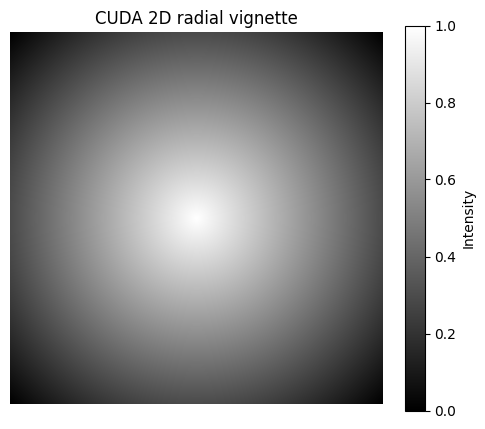

In [10]:
@cuda.jit
def radial_vignette_2d(d_canvas, width, height, center_x, center_y):
    x, y = cuda.grid(2)
    if x < width and y < height:
        dx = x - center_x
        dy = y - center_y
        dist = math.sqrt(dx * dx + dy * dy)
        max_dist = math.sqrt(center_x * center_x + center_y * center_y)
        intensity = 1.0 - (dist / max_dist)
        if intensity < 0.0:
            intensity = 0.0
        d_canvas[y, x] = intensity

WIDTH, HEIGHT = 1024, 1024
threads_2d = (16, 16)
blocks_2d = (
    (WIDTH + threads_2d[0] - 1) // threads_2d[0],
    (HEIGHT + threads_2d[1] - 1) // threads_2d[1]
)
d_canvas = cuda.to_device(np.zeros((HEIGHT, WIDTH), dtype=np.float32))
radial_vignette_2d[blocks_2d, threads_2d](
    d_canvas, WIDTH, HEIGHT, WIDTH // 2, HEIGHT // 2
)
cuda.synchronize()
result_canvas = d_canvas.copy_to_host()

center_value = float(result_canvas[HEIGHT // 2, WIDTH // 2])
corner_value = float(result_canvas[0, 0])
assert result_canvas.shape == (HEIGHT, WIDTH)
assert np.isclose(center_value, 1.0), 'Unexpected vignette center value'
assert np.isclose(corner_value, 0.0), 'Unexpected vignette corner value'
print(f'Grid blocks: X={blocks_2d[0]}, Y={blocks_2d[1]}, total={blocks_2d[0] * blocks_2d[1]}')
print(f'Canvas: {result_canvas.shape}')
print(f'Center pixel ({WIDTH // 2}, {HEIGHT // 2}): {center_value:.6f}')
print(f'Corner pixel (0, 0): {corner_value:.6f}')

import matplotlib.pyplot as plt
plt.figure(figsize=(6, 5))
plt.imshow(result_canvas, cmap='gray', vmin=0, vmax=1)
plt.title('CUDA 2D radial vignette')
plt.axis('off')
plt.colorbar(label='Intensity')
plt.show()

## Section 6 - final checksum

**Verification token: `28FCA04B35753CE1`**

Generated in the original live Colab session with Student ID **230103188**, GPU name **Tesla T4**, the existing vignette buffer (first 10x10 float32 values), and observed crossover **10000**. Only this final cell was rerun; no experiment or timing was repeated. GPU-name conversion handles both bytes and string values.


In [13]:
def generate_lab_checksum(student_id_str, d_canvas, exp_table_crossover):
    h = hashlib.sha256()
    h.update(student_id_str.strip().encode('utf-8'))

    raw_gpu_name = cuda.get_current_device().name
    gpu_name_bytes = (
        raw_gpu_name if isinstance(raw_gpu_name, bytes)
        else str(raw_gpu_name).encode('utf-8')
    )
    h.update(gpu_name_bytes)
    h.update(d_canvas.copy_to_host()[:10, :10].tobytes())
    h.update(str(exp_table_crossover).encode('utf-8'))

    digest = h.hexdigest()[:16].upper()
    print('=' * 60)
    print(f'OFFICIAL VERIFICATION CHECKSUM TOKEN: {digest}')
    print('=' * 60)
    return digest

if STUDENT_ID.strip() in ('', 'YOUR_STUDENT_ID_HERE'):
    CHECKSUM_TOKEN = None
    print('Set your real STUDENT_ID in the configuration cell and rerun this cell to generate the token.')
else:
    crossover_for_hash = CROSSOVER_N if CROSSOVER_N is not None else 'NOT_OBSERVED'
    CHECKSUM_TOKEN = generate_lab_checksum(STUDENT_ID, d_canvas, crossover_for_hash)

OFFICIAL VERIFICATION CHECKSUM TOKEN: 28FCA04B35753CE1
